# Exoplanet Discovery Biases

## Statistical comparison of NASA Exoplanet Archive discovery methods

This notebook studies how observed exoplanet properties differ across discovery methods in the NASA Exoplanet Archive. The goal is not to infer the full intrinsic population of planets, but to quantify how the observed catalog changes when planets are grouped by discovery technique.

### Scientific questions
1. Do observed orbital period, radius, and mass distributions depend on discovery method?
2. Does a simple log-log mass-radius relation provide a useful global summary, or do method-specific subsets behave differently?
3. Can a lightweight Monte Carlo selection model reproduce the qualitative direction of the observed biases?


## 0. Background: exoplanet discovery methods

Exoplanets are found with techniques that are sensitive to different parts of parameter space.

- **Transit** searches detect periodic dips in stellar brightness and are naturally biased toward short-period planets with relatively large radii.
- **Radial velocity** searches measure the stellar motion along the line of sight and are more sensitive to massive planets on closer orbits.
- **Microlensing** can reveal planets at larger separations, although catalog entries often have fewer complete physical parameters.
- **Direct imaging, timing, astrometry, and other methods** remain scientifically important, but their sample sizes or data completeness can be limiting for this comparison.

These selection effects mean that catalog distributions of period, radius, and mass should be interpreted as observed distributions, not as an unbiased census of all exoplanets.


## 1. Libraries and settings


In [1]:
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from iminuit import Minuit
from iminuit.cost import LeastSquares

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)


## 2. Download data from the NASA Exoplanet Archive

The notebook queries the `pscomppars` table through the archive TAP endpoint and keeps the columns needed for the analysis.


In [2]:
QUERY = """
select
    pl_name,
    discoverymethod,
    disc_year,
    pl_orbper,
    pl_rade,
    pl_bmasse,
    pl_orbeccen,
    st_mass,
    st_rad,
    sy_dist
from pscomppars
where discoverymethod is not null
"""

URL = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=" + requests.utils.quote(QUERY) +
    "&format=csv"
)

def download_exoplanet_data(url: str = URL) -> pd.DataFrame:
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    return pd.read_csv(io.StringIO(response.text))


In [3]:
df_raw = download_exoplanet_data()
df_raw.head()


,pl_name,discoverymethod,disc_year,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,st_mass,st_rad,sy_dist
0,Kepler-1167 b,Transit,2016.0,1.003934,1.710000,3.570,0.0,0.790,0.750,820.905
1,Kepler-1740 b,Transit,2021.0,8.172400,3.323214,11.000,0.0,0.943,0.905,1061.770
2,Kepler-1581 b,Transit,2016.0,6.283855,0.800000,0.437,0.0,1.120,1.230,493.175
3,Kepler-644 b,Transit,2016.0,3.173917,3.150000,10.100,0.0,1.490,1.810,1318.050
4,Kepler-1752 b,Transit,2021.0,56.358501,4.540605,18.700,0.0,0.824,0.821,962.888


In [4]:
print("Shape:", df_raw.shape)
df_raw.info()


Shape: (6291, 10)
<class 'pandas.DataFrame'>
RangeIndex: 6291 entries, 0 to 6290
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6291 non-null   str    
 1   discoverymethod  6291 non-null   str    
 2   disc_year        6290 non-null   float64
 3   pl_orbper        5951 non-null   float64
 4   pl_rade          6241 non-null   float64
 5   pl_bmasse        6260 non-null   float64
 6   pl_orbeccen      5241 non-null   float64
 7   st_mass          6282 non-null   float64
 8   st_rad           5973 non-null   float64
 9   sy_dist          6264 non-null   float64
dtypes: float64(8), str(2)
memory usage: 491.6 KB


### Discovery methods in the raw data

The table below counts planets by discovery method in the downloaded catalog. The main analysis keeps methods with enough planets to support meaningful statistical comparisons.


In [5]:
method_counts_raw = (
    df_raw["discoverymethod"]
    .value_counts()
    .rename_axis("discoverymethod")
    .reset_index(name="n_planets")
)
method_counts_raw


,discoverymethod,n_planets
0,Transit,4651
1,Radial Velocity,1181
2,Microlensing,278
3,Imaging,97
4,Transit Timing Variations,41
5,Eclipse Timing Variations,17
6,Orbital Brightness Modulation,9
7,Pulsar Timing,8
8,Astrometry,6
9,Pulsation Timing Variations,2


In [6]:
MIN_METHOD_COUNT = 100

method_selection = method_counts_raw.copy()
method_selection["included_by_count"] = method_selection["n_planets"] >= MIN_METHOD_COUNT
method_selection["selection_note"] = np.where(
    method_selection["included_by_count"],
    "included: enough planets for the main analysis",
    "excluded from the main analysis: too few planets",
)
method_selection


,discoverymethod,n_planets,included_by_count,selection_note
0,Transit,4651,True,included: enough planets for the main analysis
1,Radial Velocity,1181,True,included: enough planets for the main analysis
2,Microlensing,278,True,included: enough planets for the main analysis
3,Imaging,97,False,excluded from the main analysis: too few planets
4,Transit Timing Variations,41,False,excluded from the main analysis: too few planets
5,Eclipse Timing Variations,17,False,excluded from the main analysis: too few planets
6,Orbital Brightness Modulation,9,False,excluded from the main analysis: too few planets
7,Pulsar Timing,8,False,excluded from the main analysis: too few planets
8,Astrometry,6,False,excluded from the main analysis: too few planets
9,Pulsation Timing Variations,2,False,excluded from the main analysis: too few planets


## 3. Initial data cleaning


In [7]:
NUMERIC_COLUMNS = [
    "disc_year",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "st_mass",
    "st_rad",
    "sy_dist",
]

def prepare_dataset(df: pd.DataFrame) -> pd.DataFrame:
    clean = df.copy()

    for col in NUMERIC_COLUMNS:
        if col in clean.columns:
            clean[col] = pd.to_numeric(clean[col], errors="coerce")

    clean = clean.drop_duplicates(subset=["pl_name"])
    clean["discoverymethod"] = clean["discoverymethod"].astype(str).str.strip()

    for col in ["pl_orbper", "pl_rade", "pl_bmasse", "st_mass", "st_rad", "sy_dist"]:
        if col in clean.columns:
            clean.loc[clean[col] <= 0, col] = np.nan

    return clean


In [8]:
df = prepare_dataset(df_raw)
print("Shape after initial cleaning:", df.shape)
df.head()


Shape after initial cleaning: (6291, 10)


,pl_name,discoverymethod,disc_year,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,st_mass,st_rad,sy_dist
0,Kepler-1167 b,Transit,2016.0,1.003934,1.710000,3.570,0.0,0.790,0.750,820.905
1,Kepler-1740 b,Transit,2021.0,8.172400,3.323214,11.000,0.0,0.943,0.905,1061.770
2,Kepler-1581 b,Transit,2016.0,6.283855,0.800000,0.437,0.0,1.120,1.230,493.175
3,Kepler-644 b,Transit,2016.0,3.173917,3.150000,10.100,0.0,1.490,1.810,1318.050
4,Kepler-1752 b,Transit,2021.0,56.358501,4.540605,18.700,0.0,0.824,0.821,962.888


In [9]:
missing_summary = (
    df[["pl_orbper", "pl_rade", "pl_bmasse", "pl_orbeccen", "st_mass", "st_rad", "sy_dist"]]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
)
missing_summary


pl_orbeccen    0.166905
pl_orbper      0.054045
st_rad         0.050548
pl_rade        0.007948
pl_bmasse      0.004928
sy_dist        0.004292
st_mass        0.001431
Name: missing_fraction, dtype: float64

### Data completeness by discovery method

Before running statistical tests, it is useful to inspect how many non-null values remain for each physical variable and discovery method. This prevents over-interpreting comparisons based on very small subsets.


In [10]:
missing_by_method = (
    df.groupby("discoverymethod")[["pl_orbper", "pl_rade", "pl_bmasse", "pl_orbeccen", "st_mass", "st_rad", "sy_dist"]]
    .apply(lambda g: g.notna().mean())
    .sort_index()
)
missing_by_method


,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,st_mass,st_rad,sy_dist
discoverymethod,,,,,,,
Astrometry,1.000000,1.000000,1.000000,1.000000,1.000000,0.833333,1.000000
Disk Kinematics,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
Eclipse Timing Variations,1.000000,0.882353,1.000000,0.941176,1.000000,0.588235,0.941176
Imaging,0.257732,0.958763,0.969072,0.268041,0.917526,0.804124,0.938144
Microlensing,0.043165,1.000000,1.000000,0.010791,1.000000,0.003597,0.992806
Orbital Brightness Modulation,1.000000,0.666667,0.666667,0.111111,1.000000,1.000000,1.000000
Pulsar Timing,0.875000,0.750000,1.000000,0.750000,1.000000,0.000000,0.750000
Pulsation Timing Variations,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Radial Velocity,1.000000,0.968671,0.999153,0.964437,1.000000,0.994920,0.999153


In [11]:
nonmissing_counts = (
    df.groupby("discoverymethod")[["pl_orbper", "pl_rade", "pl_bmasse", "pl_orbeccen", "st_mass", "st_rad", "sy_dist"]]
    .count()
    .sort_values("pl_orbper", ascending=False)
)
nonmissing_counts


,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,st_mass,st_rad,sy_dist
discoverymethod,,,,,,,
Transit,4651,4650,4628,4003,4650,4651,4636
Radial Velocity,1181,1144,1180,1139,1181,1175,1180
Transit Timing Variations,41,40,40,39,41,41,41
Imaging,25,93,94,26,89,78,91
Eclipse Timing Variations,17,15,17,16,17,10,16
Microlensing,12,278,278,3,278,1,276
Orbital Brightness Modulation,9,6,6,1,9,9,9
Pulsar Timing,7,6,8,6,8,0,6
Astrometry,6,6,6,6,6,5,6


## 4. Main sample selection


In [12]:
def filter_main_methods(df: pd.DataFrame, min_count: int = 100) -> pd.DataFrame:
    counts = df["discoverymethod"].value_counts()
    valid_methods = counts[counts >= min_count].index
    return df[df["discoverymethod"].isin(valid_methods)].copy()

def add_log_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for source, target in [
        ("pl_orbper", "log_orbper"),
        ("pl_rade", "log_rade"),
        ("pl_bmasse", "log_bmasse"),
    ]:
        if source in out.columns:
            out[target] = np.log10(out[source])

    return out


In [13]:
df = filter_main_methods(df, min_count=MIN_METHOD_COUNT)
df = add_log_columns(df)

print("Selected sample shape:", df.shape)
df["discoverymethod"].value_counts()


Selected sample shape: (6110, 13)


discoverymethod
Transit            4651
Radial Velocity    1181
Microlensing        278
Name: count, dtype: int64

## 5. Descriptive analysis


In [14]:
def summarize_by_method(df: pd.DataFrame) -> pd.DataFrame:
    variables = ["log_orbper", "log_rade", "log_bmasse"]
    rows = []

    for method, subdf in df.groupby("discoverymethod"):
        row = {"discoverymethod": method, "n_planets": len(subdf)}
        for col in variables:
            data = subdf[col].dropna()
            row[f"{col}_n"] = len(data)
            row[f"{col}_mean"] = data.mean()
            row[f"{col}_std"] = data.std(ddof=1)
            row[f"{col}_median"] = data.median()
            row[f"{col}_q25"] = data.quantile(0.25)
            row[f"{col}_q75"] = data.quantile(0.75)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("n_planets", ascending=False)

summary_table = summarize_by_method(df)
summary_table


,discoverymethod,n_planets,log_orbper_n,log_orbper_mean,log_orbper_std,log_orbper_median,log_orbper_q25,log_orbper_q75,log_rade_n,log_rade_mean,log_rade_std,log_rade_median,log_rade_q25,log_rade_q75,log_bmasse_n,log_bmasse_mean,log_bmasse_std,log_bmasse_median,log_bmasse_q25,log_bmasse_q75
2,Transit,4651,4651,0.950448,0.543286,0.903403,0.581091,1.274201,4650,0.466540,0.360315,0.388989,0.214380,0.597695,4628,1.046396,0.822281,0.838849,0.539076,1.283865
1,Radial Velocity,1181,1181,2.274560,1.060179,2.474508,1.326377,3.049912,1144,0.892656,0.341309,1.100371,0.613572,1.127105,1180,2.258896,1.048087,2.538090,1.232518,3.136165
0,Microlensing,278,12,3.529988,0.276115,3.496828,3.379964,3.677230,278,0.921763,0.302924,1.096910,0.714539,1.130334,278,2.173539,0.934984,2.273412,1.369679,2.937514


In [15]:
def plot_histograms_by_method(df: pd.DataFrame, column: str, bins: int = 30) -> None:
    plt.figure(figsize=(8, 5))

    for method, subdf in df.groupby("discoverymethod"):
        data = subdf[column].dropna()
        if len(data) > 0:
            plt.hist(data, bins=bins, density=True, histtype="step", label=method)

    plt.xlabel(column)
    plt.ylabel("density")
    plt.title(f"Distribution of {column} by discovery method")
    plt.legend()
    plt.tight_layout()
    plt.show()


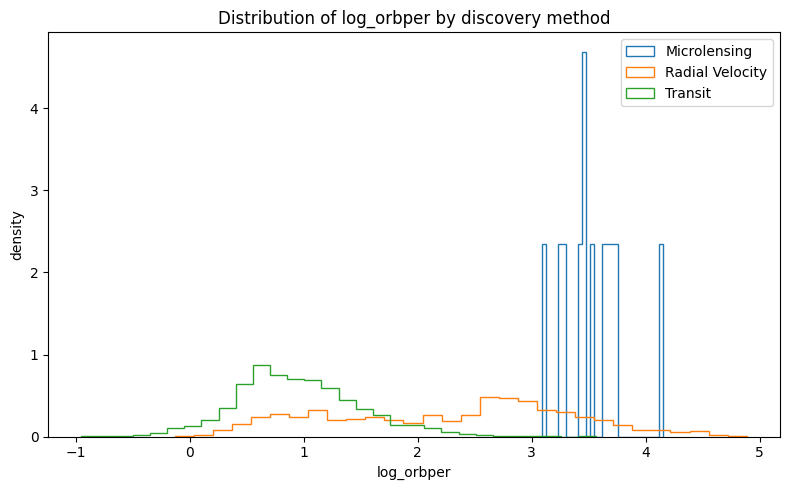

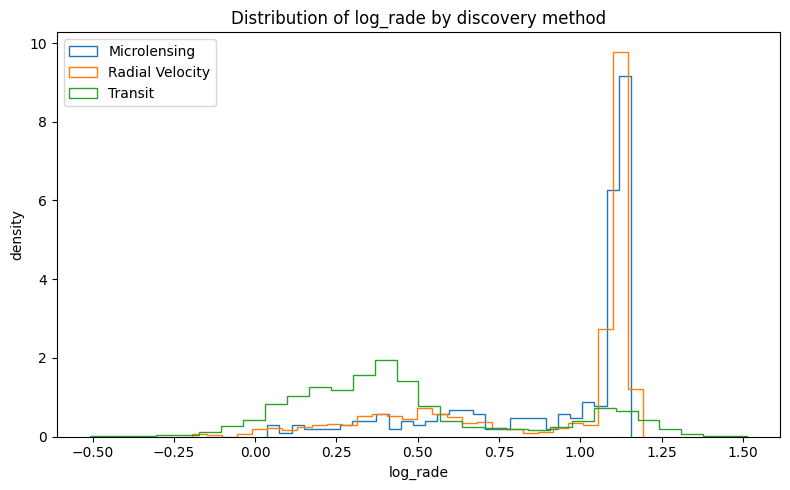

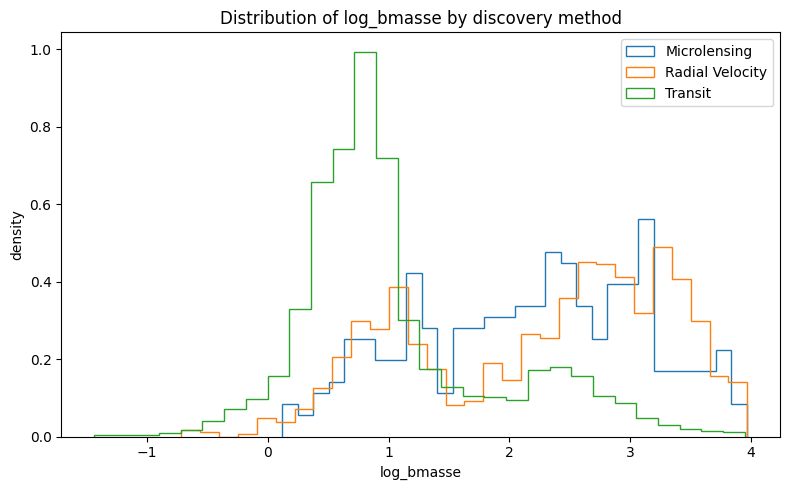

In [16]:
plot_histograms_by_method(df, "log_orbper")
plot_histograms_by_method(df, "log_rade")
plot_histograms_by_method(df, "log_bmasse")


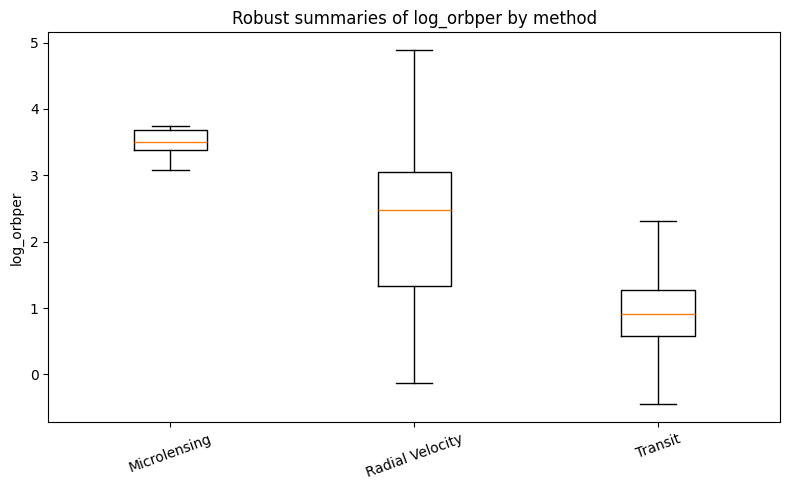

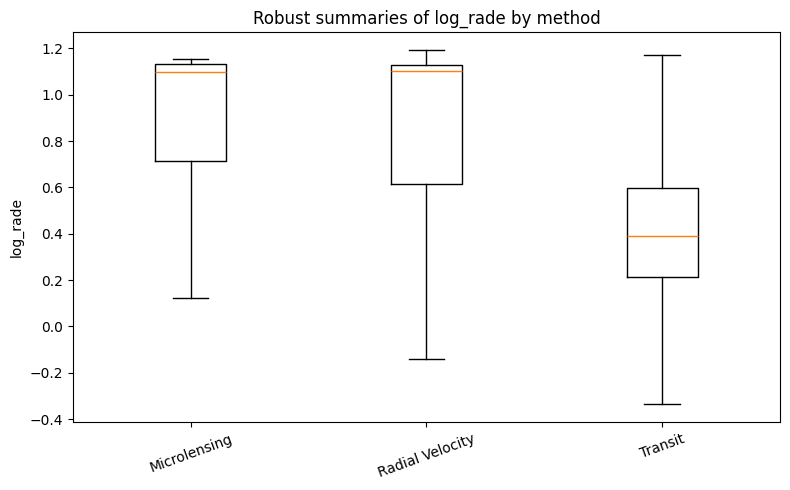

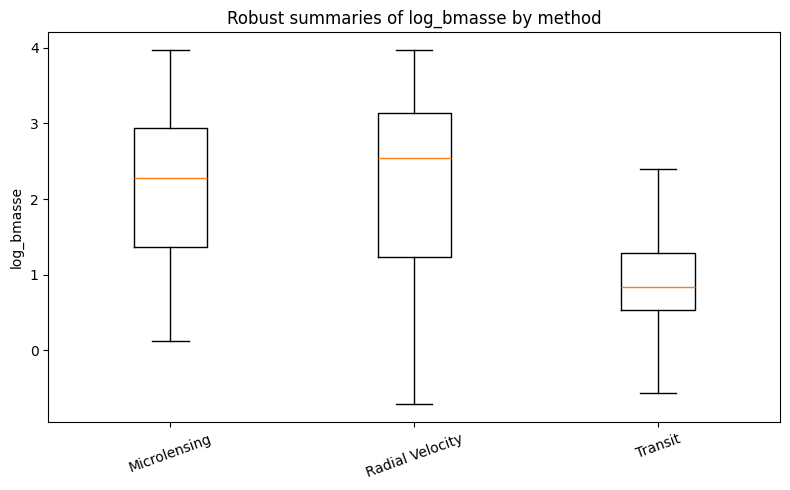

In [17]:
def plot_boxplot_by_method(df: pd.DataFrame, column: str) -> None:
    groups = [subdf[column].dropna().values for _, subdf in df.groupby("discoverymethod")]
    labels = [method for method, _ in df.groupby("discoverymethod")]

    plt.figure(figsize=(8, 5))
    plt.boxplot(groups, tick_labels=labels, showfliers=False)
    plt.ylabel(column)
    plt.title(f"Robust summaries of {column} by method")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plot_boxplot_by_method(df, "log_orbper")
plot_boxplot_by_method(df, "log_rade")
plot_boxplot_by_method(df, "log_bmasse")


In [18]:
def plot_ecdf_by_method(df: pd.DataFrame, column: str) -> None:
    plt.figure(figsize=(8, 5))

    for method, subdf in df.groupby("discoverymethod"):
        x = np.sort(subdf[column].dropna().values)
        if len(x) == 0:
            continue
        y = np.arange(1, len(x) + 1) / len(x)
        plt.step(x, y, where="post", label=method)

    plt.xlabel(column)
    plt.ylabel("ECDF")
    plt.title(f"ECDF of {column} by discovery method")
    plt.legend()
    plt.tight_layout()
    plt.show()


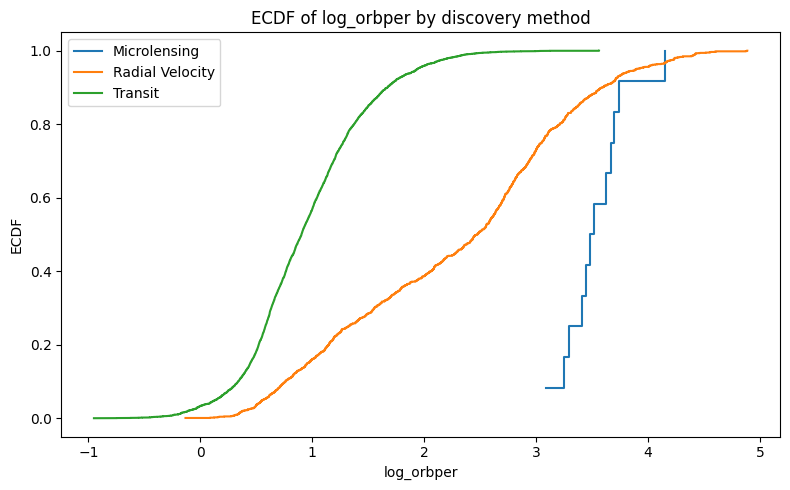

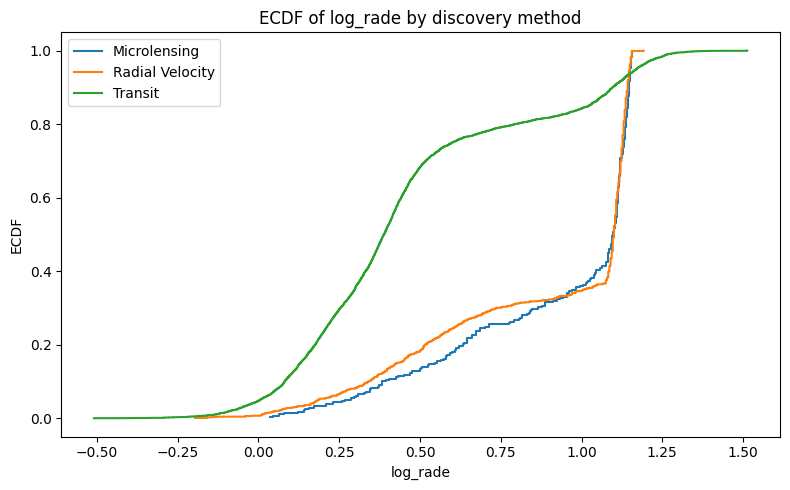

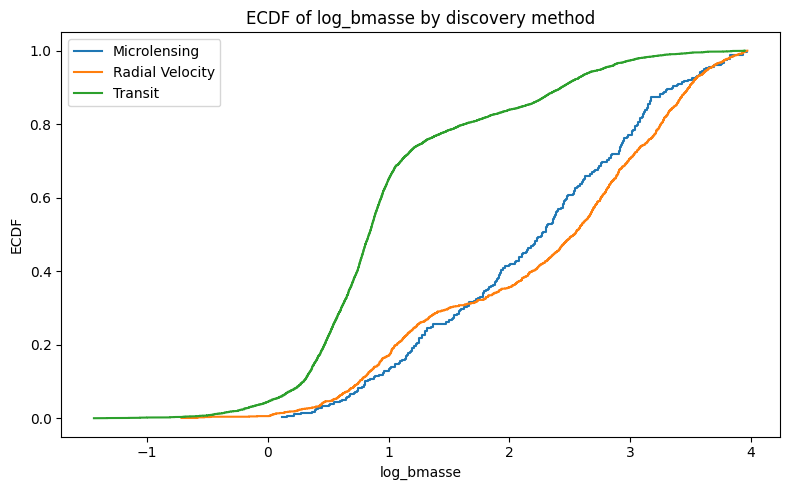

In [19]:
plot_ecdf_by_method(df, "log_orbper")
plot_ecdf_by_method(df, "log_rade")
plot_ecdf_by_method(df, "log_bmasse")


### Relationships among quantitative variables

Correlation and covariance provide a compact summary of how orbital period, radius, and mass co-vary in the selected sample.


In [20]:
log_variables = ["log_orbper", "log_rade", "log_bmasse"]

correlation_matrix = df[log_variables].corr()
covariance_matrix = df[log_variables].cov()

correlation_matrix


,log_orbper,log_rade,log_bmasse
log_orbper,1.000000,0.410403,0.474337
log_rade,0.410403,1.000000,0.920299
log_bmasse,0.474337,0.920299,1.000000


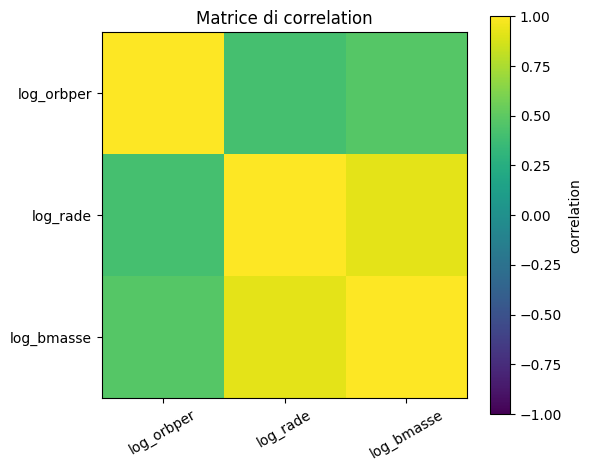

In [21]:
plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix, vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(log_variables)), log_variables, rotation=30)
plt.yticks(range(len(log_variables)), log_variables)
plt.title("Matrice di correlation")
plt.tight_layout()
plt.show()


## 6. Hypothesis tests across discovery methods


In [22]:
def pairwise_ks_tests(df: pd.DataFrame, column: str, min_n: int = 30) -> pd.DataFrame:
    methods = sorted(df["discoverymethod"].dropna().unique())
    rows = []

    for i, m1 in enumerate(methods):
        for m2 in methods[i + 1:]:
            x1 = df.loc[df["discoverymethod"] == m1, column].dropna()
            x2 = df.loc[df["discoverymethod"] == m2, column].dropna()

            if len(x1) < min_n or len(x2) < min_n:
                continue

            stat, pvalue = stats.ks_2samp(x1, x2)
            rows.append({
                "column": column,
                "method_1": m1,
                "method_2": m2,
                "ks_stat": stat,
                "pvalue": pvalue,
                "n1": len(x1),
                "n2": len(x2),
            })

    return pd.DataFrame(rows).sort_values("pvalue")


In [23]:
ks_orbper = pairwise_ks_tests(df, "log_orbper")
ks_rade = pairwise_ks_tests(df, "log_rade")
ks_mass = pairwise_ks_tests(df, "log_bmasse")

ks_orbper.head(10)


,column,method_1,method_2,ks_stat,pvalue,n1,n2
0,log_orbper,Radial Velocity,Transit,0.580098,2.190423e-296,1181,4651


In [24]:
ks_rade.head(10)


,column,method_1,method_2,ks_stat,pvalue,n1,n2
2,log_rade,Radial Velocity,Transit,0.515663,1.190531e-224,1144,4650
1,log_rade,Microlensing,Transit,0.580651,5.107677e-84,278,4650
0,log_rade,Microlensing,Radial Velocity,0.073370,1.698659e-01,278,1144


In [25]:
ks_mass.head(10)


,column,method_1,method_2,ks_stat,pvalue,n1,n2
2,log_bmasse,Radial Velocity,Transit,0.493934,5.198420e-210,1180,4628
1,log_bmasse,Microlensing,Transit,0.553265,1.249282e-75,278,4628
0,log_bmasse,Microlensing,Radial Velocity,0.123357,1.905618e-03,278,1180


### Chi-square test on binned variables

The Kolmogorov-Smirnov test compares continuous distributions. As a complementary check, the notebook bins each variable into quantiles and tests whether discovery method and variable bin are independent.


In [26]:
def chi_square_independence_binned(df: pd.DataFrame, column: str, q: int = 4):
    tmp = df.dropna(subset=["discoverymethod", column]).copy()
    tmp["bin"] = pd.qcut(tmp[column], q=q, duplicates="drop")

    observed = pd.crosstab(tmp["discoverymethod"], tmp["bin"])
    obs = observed.values.astype(float)
    expected = np.outer(obs.sum(axis=1), obs.sum(axis=0)) / obs.sum()

    chi2_obs = ((obs - expected) ** 2 / expected).sum()
    ndof = (obs.shape[0] - 1) * (obs.shape[1] - 1)
    pvalue = stats.chi2.sf(chi2_obs, ndof)

    result = pd.DataFrame({
        "column": [column],
        "chi2": [chi2_obs],
        "ndof": [ndof],
        "pvalue": [pvalue],
        "min_expected": [expected.min()],
    })
    return observed, result

period_table, chi_period = chi_square_independence_binned(df, "log_orbper", q=4)
chi_period


,column,chi2,ndof,pvalue,min_expected
0,log_orbper,1674.627691,6,0.0,3.0


In [27]:
radius_table, chi_radius = chi_square_independence_binned(df, "log_rade", q=4)
mass_table, chi_mass = chi_square_independence_binned(df, "log_bmasse", q=4)
pd.concat([chi_period, chi_radius, chi_mass], ignore_index=True)


,column,chi2,ndof,pvalue,min_expected
0,log_orbper,1674.627691,6,0.000000e+00,3.000000
1,log_rade,1538.664100,6,0.000000e+00,69.362648
2,log_bmasse,1353.756654,6,2.493172e-289,69.248768


## 7. Bootstrap estimates for summary statistics


In [28]:
def bootstrap_statistic(values: np.ndarray, statistic=np.median, n_boot: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        raise ValueError("Empty array after removing NaN values.")

    samples = np.empty(n_boot)
    for i in range(n_boot):
        boot = rng.choice(values, size=len(values), replace=True)
        samples[i] = statistic(boot)

    return samples

def bootstrap_ci(values: np.ndarray, statistic=np.median, n_boot: int = 2000, alpha: float = 0.05):
    samples = bootstrap_statistic(values, statistic=statistic, n_boot=n_boot)
    lower = np.quantile(samples, alpha / 2)
    upper = np.quantile(samples, 1 - alpha / 2)
    return lower, upper, samples


In [29]:
example_method = df["discoverymethod"].value_counts().index[0]
example_values = df.loc[df["discoverymethod"] == example_method, "log_orbper"].dropna().values

ci_low, ci_high, boot_samples = bootstrap_ci(example_values, statistic=np.median)
print("Method:", example_method)
print("95% bootstrap CI for the median of log_orbper:", (ci_low, ci_high))


Method: Transit
95% bootstrap CI for the median of log_orbper: (np.float64(0.8825247656321377), np.float64(0.9186129517365064))


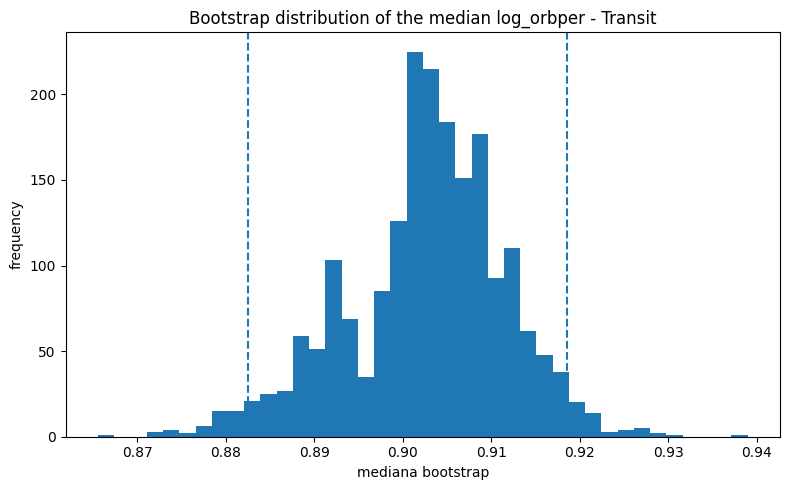

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(boot_samples, bins=40)
plt.axvline(ci_low, linestyle="--")
plt.axvline(ci_high, linestyle="--")
plt.title(f"Bootstrap distribution of the median log_orbper - {example_method}")
plt.xlabel("mediana bootstrap")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


## 8. Mass-radius relation


In [31]:
def mass_radius_sample(df: pd.DataFrame) -> pd.DataFrame:
    sub = df.dropna(subset=["pl_bmasse", "pl_rade"]).copy()
    sub = sub[(sub["pl_bmasse"] > 0) & (sub["pl_rade"] > 0)]
    sub["log_mass"] = np.log10(sub["pl_bmasse"])
    sub["log_radius"] = np.log10(sub["pl_rade"])
    return sub

def linear_model(x, a, b):
    return a + b * x

def fit_mass_radius_linear(df: pd.DataFrame):
    x = df["log_mass"].values
    y = df["log_radius"].values

    if len(y) < 3:
        raise ValueError("At least three points are required to estimate intercept, slope, and residuals.")

    first_cost = LeastSquares(x, y, np.ones_like(y), linear_model)
    first_fit = Minuit(first_cost, a=0.0, b=0.3)
    first_fit.migrad()
    first_fit.hesse()

    first_residuals = y - linear_model(x, first_fit.values["a"], first_fit.values["b"])
    ndof = len(y) - 2
    residual_std = np.sqrt(np.sum(first_residuals ** 2) / ndof)
    if not np.isfinite(residual_std) or residual_std <= 0:
        residual_std = 1.0

    yerr = np.full_like(y, residual_std)
    cost = LeastSquares(x, y, yerr, linear_model)
    fit = Minuit(cost, a=first_fit.values["a"], b=first_fit.values["b"])
    fit.migrad()
    fit.hesse()

    a = float(fit.values["a"])
    b = float(fit.values["b"])
    y_pred = linear_model(x, a, b)
    residuals = y - y_pred

    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    chi2_value = float(fit.fval)
    pvalue = stats.chi2.sf(chi2_value, ndof)

    covariance = np.array(fit.covariance) if fit.covariance is not None else np.full((2, 2), np.nan)

    return {
        "intercept": a,
        "slope": b,
        "intercept_err": float(fit.errors["a"]),
        "slope_err": float(fit.errors["b"]),
        "r2": float(r2),
        "chi2": chi2_value,
        "ndof": int(ndof),
        "chi2_ndof": chi2_value / ndof,
        "pvalue_chi2": float(pvalue),
        "residual_std": float(residual_std),
        "cov": covariance,
        "minuit": fit,
        "y_pred": y_pred,
    }

def plot_mass_radius_fit(df: pd.DataFrame, fit_result: dict, title: str = "Mass-radius fit with Minuit") -> None:
    plt.figure(figsize=(7, 5))
    plt.scatter(df["log_mass"], df["log_radius"], alpha=0.35, s=12)

    x_grid = np.linspace(df["log_mass"].min(), df["log_mass"].max(), 200)
    y_grid = linear_model(x_grid, fit_result["intercept"], fit_result["slope"])

    plt.plot(x_grid, y_grid, color="black")
    plt.xlabel("log10(Earth masses)")
    plt.ylabel("log10(Earth radii)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [32]:
mr = mass_radius_sample(df)
print("Mass-radius sample size:", mr.shape)

fit_global = fit_mass_radius_linear(mr)
fit_global


Mass-radius sample size: (6049, 15)


{'intercept': 0.08444855731725635,
 'slope': 0.36384488126702325,
 'intercept_err': 0.003304135538351033,
 'slope_err': 0.0019890013657849056,
 'r2': 0.8469493937847128,
 'chi2': 6046.999999999999,
 'ndof': 6047,
 'chi2_ndof': 0.9999999999999999,
 'pvalue_chi2': 0.4975815638715709,
 'residual_std': 0.15563373425463506,
 'cov': array([[ 1.09173117e-05, -5.22961253e-06],
        [-5.22961253e-06,  3.95612643e-06]]),
 'minuit': ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6047 (χ²/ndof = 1.0)       │              Nfcn = 30               │
│ EDM = 2.19e-19 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼───

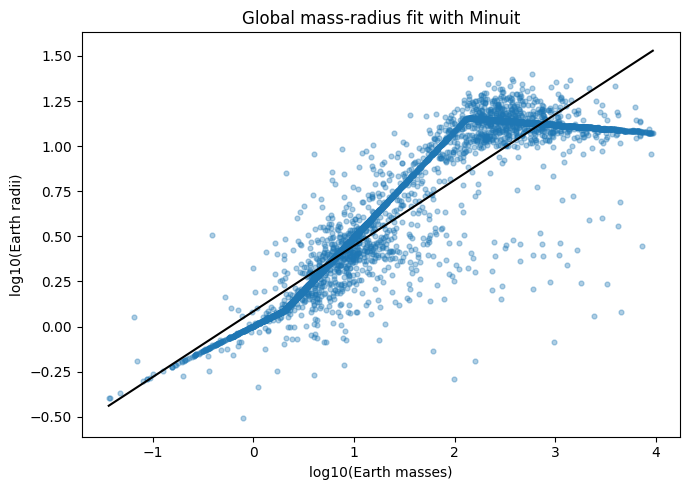

In [33]:
plot_mass_radius_fit(mr, fit_global, title="Global mass-radius fit with Minuit")


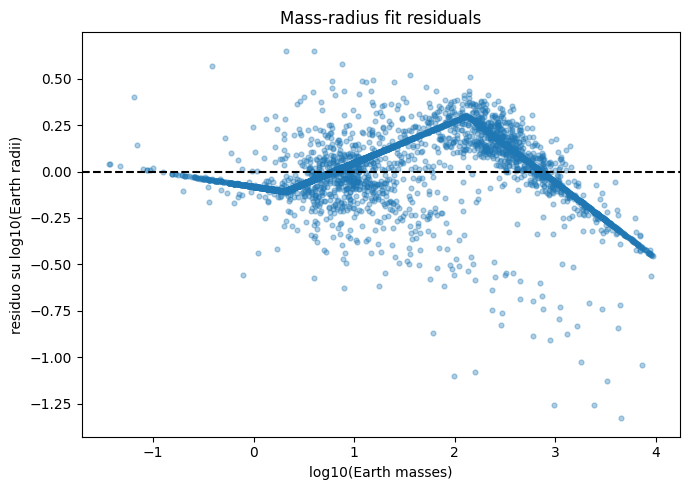

In [34]:
mr = mr.copy()
mr["fit_residual"] = mr["log_radius"] - linear_model(
    mr["log_mass"], fit_global["intercept"], fit_global["slope"]
)

plt.figure(figsize=(7, 5))
plt.scatter(mr["log_mass"], mr["fit_residual"], alpha=0.35, s=12)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("log10(Earth masses)")
plt.ylabel("residuo su log10(Earth radii)")
plt.title("Mass-radius fit residuals")
plt.tight_layout()
plt.show()


In [35]:
def fit_by_method_mass_radius(df: pd.DataFrame, min_count: int = 30) -> pd.DataFrame:
    rows = []

    for method, subdf in df.groupby("discoverymethod"):
        if len(subdf) < min_count:
            continue
        result = fit_mass_radius_linear(subdf)
        rows.append({
            "method": method,
            "n": len(subdf),
            "intercept": result["intercept"],
            "slope": result["slope"],
            "r2": result["r2"],
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


In [36]:
fit_methods = fit_by_method_mass_radius(mr, min_count=30)
fit_methods


,method,n,intercept,slope,r2
2,Transit,4627,0.047570,0.397082,0.832980
1,Radial Velocity,1144,0.247570,0.289402,0.791256
0,Microlensing,278,0.320269,0.276735,0.729573


### Bootstrap and Minuit

The main mass-radius fit uses `Minuit` with a least-squares cost. For the bootstrap distribution of the slope, `scipy.stats.linregress` is used as a faster estimator on many resampled datasets.


In [37]:
def bootstrap_mass_radius_slope(df: pd.DataFrame, n_boot: int = 1000, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    slopes = np.empty(n_boot)

    arr = df[["log_mass", "log_radius"]].dropna().values
    n = len(arr)

    for i in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        boot = arr[idx]
        slope, intercept, r_value, p_value, std_err = stats.linregress(boot[:, 0], boot[:, 1])
        slopes[i] = slope

    return slopes


In [38]:
slope_samples = bootstrap_mass_radius_slope(mr, n_boot=1000)
np.quantile(slope_samples, [0.025, 0.5, 0.975])


array([0.35877545, 0.36405182, 0.36939405])

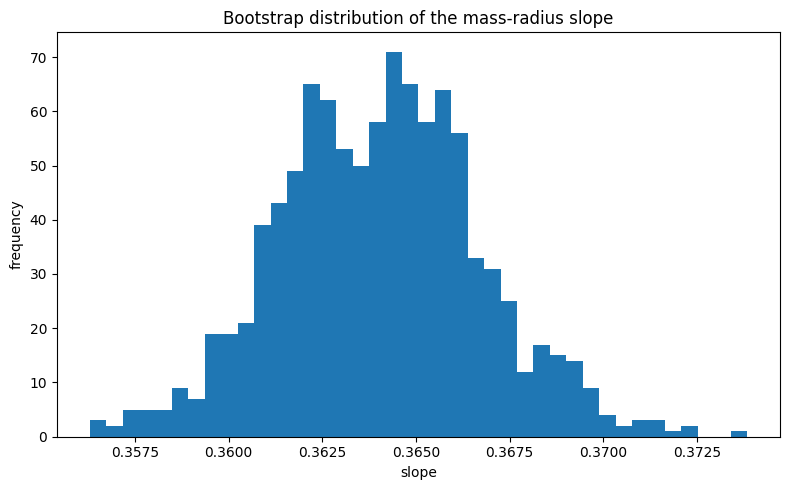

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(slope_samples, bins=40)
plt.title("Bootstrap distribution of the mass-radius slope")
plt.xlabel("slope")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


## 9. Monte Carlo simulation of observational bias


In [40]:
def simulate_planet_population(n: int = 20000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    log_mass = rng.normal(loc=0.5, scale=0.7, size=n)
    log_period = rng.normal(loc=1.5, scale=0.8, size=n)
    log_radius = 0.3 + 0.35 * log_mass + rng.normal(0, 0.15, size=n)

    return pd.DataFrame({
        "log_mass": log_mass,
        "log_period": log_period,
        "log_radius": log_radius,
    })

def transit_detection_probability(pop: pd.DataFrame) -> np.ndarray:
    score = 1.2 * pop["log_radius"] - 0.9 * pop["log_period"]
    prob = 1 / (1 + np.exp(-score))
    return np.clip(prob, 0, 1)

def rv_detection_probability(pop: pd.DataFrame) -> np.ndarray:
    score = 1.1 * pop["log_mass"] - 0.5 * pop["log_period"]
    prob = 1 / (1 + np.exp(-score))
    return np.clip(prob, 0, 1)

def observe_population(pop: pd.DataFrame, prob: np.ndarray, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    u = rng.random(len(pop))
    return pop.loc[u < prob].copy()


In [41]:
pop = simulate_planet_population()
transit_obs = observe_population(pop, transit_detection_probability(pop), seed=1)
rv_obs = observe_population(pop, rv_detection_probability(pop), seed=2)

print("Total population:", len(pop))
print("Observed by transit:", len(transit_obs))
print("Observed by radial velocity:", len(rv_obs))


Total population: 20000
Observed by transit: 6769
Observed by radial velocity: 9167


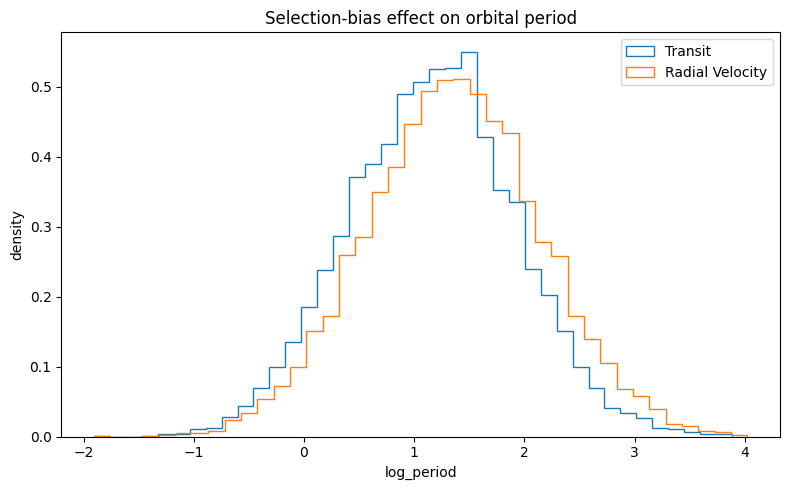

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(transit_obs["log_period"], bins=40, density=True, histtype="step", label="Transit")
plt.hist(rv_obs["log_period"], bins=40, density=True, histtype="step", label="Radial Velocity")
plt.xlabel("log_period")
plt.ylabel("density")
plt.title("Selection-bias effect on orbital period")
plt.legend()
plt.tight_layout()
plt.show()


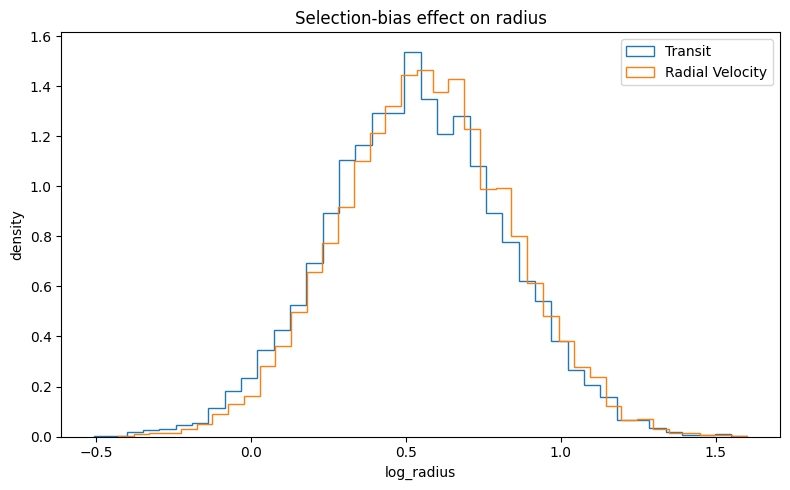

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(transit_obs["log_radius"], bins=40, density=True, histtype="step", label="Transit")
plt.hist(rv_obs["log_radius"], bins=40, density=True, histtype="step", label="Radial Velocity")
plt.xlabel("log_radius")
plt.ylabel("density")
plt.title("Selection-bias effect on radius")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Conclusions from this run

This executed notebook was generated on 2026-05-28 using the then-current NASA Exoplanet Archive response.

The downloaded catalog contains **6,291 planets** with a non-null discovery method. Applying the minimum-count threshold of 100 planets keeps three methods in the main comparison: **Transit** (4,651 planets), **Radial Velocity** (1,181 planets), and **Microlensing** (278 planets). These counts already show why the analysis should be interpreted as a comparison of observed catalog samples rather than as an unbiased census of the intrinsic exoplanet population.

The descriptive statistics and ECDFs show strong method-dependent differences. Transit detections have much shorter orbital periods, with a median `log_orbper` of about **0.90**, while Radial Velocity planets have a median around **2.47**. Microlensing has only 12 non-missing orbital-period values in this query, so its period-based results should be treated cautiously. Radius and mass also differ by method: Transit planets have lower median `log_rade` and `log_bmasse` than the Radial Velocity and Microlensing samples.

The hypothesis tests support the visual picture. The KS comparison between Radial Velocity and Transit orbital periods is highly significant (`p ≈ 2.19e-296`). For radius and mass, the strongest differences also involve Transit versus the other methods. The chi-square tests on binned variables reject independence between discovery method and the binned physical variables for period, radius, and mass, again indicating that discovery method is a major selection variable.

The global log-log mass-radius fit uses **6,049 planets** and gives a slope of **0.3638 ± 0.0020**, with `R² ≈ 0.847`. The bootstrap 95% interval for the slope is approximately **[0.3588, 0.3694]**. Method-specific fits differ noticeably: Transit has slope **0.397**, Radial Velocity **0.289**, and Microlensing **0.277**. This suggests that the global fit is useful as a compact descriptive baseline, but it should not be interpreted as a universal physical law across all discovery-selected subsamples.

The Monte Carlo toy model detects **6,769** planets through the transit-like selection rule and **9,167** through the radial-velocity-like rule out of a simulated population of 20,000. The simulated observed distributions shift in the expected qualitative directions, illustrating how different detection probabilities can reshape the same underlying population into different observed samples.

Overall, the main result is that the NASA Exoplanet Archive sample analyzed here contains strong observational selection effects. Discovery method must be considered explicitly before interpreting period, radius, mass, or fitted mass-radius trends as physical population properties.

